# DETECTING AI GENERATED TEXT

##### The Training Dataset given in the Keggle Compition have mostly student written essays, so I will be using other datasets which contains
##### both AI generated and student generated essays.
##### Datasets are extracted from :
- https://www.kaggle.com/datasets/nbroad/daigt-data-llama-70b-and-falcon180b
- https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset

In [1]:
import numpy as np
import pandas as pd
from pdb import set_trace
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.set_option("display.width", 400)

seed = 123
n_grams = (1, 2)
num_folds = 5
debug = False


In [2]:
main_df = pd \
    .read_csv("train_v2_drcat_02.csv") \
    .assign(tokenized_text="") \
    .drop(labels="RDizzl3_seven",axis=1)
main_df

,text,label,prompt_name,source,tokenized_text
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,
...,...,...,...,...,...
44863,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,
44864,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,
44865,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,
44866,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,


In [3]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

<Axes: title={'center': 'Label distribution'}, xlabel='Label', ylabel='Number of Essays'>

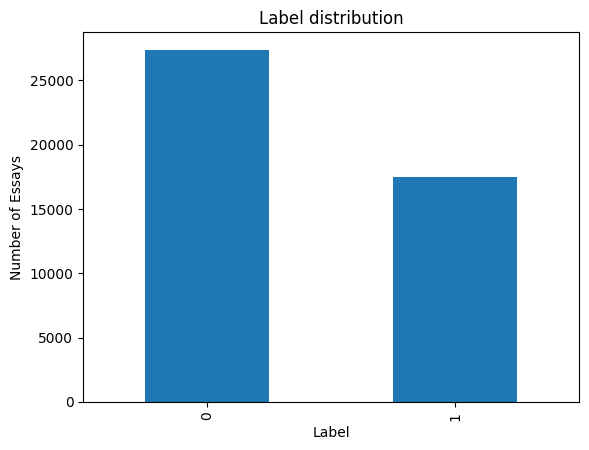

In [4]:
main_df["label"].value_counts().plot(kind="bar",title="Label distribution",xlabel="Label",ylabel="Number of Essays")

In [5]:
llama_falcon_df = pd \
    .read_csv(f"llama_falcon_v3.csv") \
    .assign(tokenized_text="") \
    .rename(columns={"generated": "label", "model": "source"})
llama_falcon_df

,text,label,prompt_name,source,tokenized_text
0,One way we can make a positive change is by li...,1,Car-free cities,llama_70b,
1,The experimental district of Vauban in Germany...,1,Car-free cities,llama_70b,
2,"The successful ""Day Without Cars"" event in Bog...",1,Car-free cities,llama_70b,
3,"The exhaust from cars pollutes our air, and th...",1,Car-free cities,llama_70b,
4,"Recently, Paris faced a severe pollution probl...",1,Car-free cities,llama_70b,
...,...,...,...,...,...
6995,"Driverless cars, also known as autonomous cars...",1,Driverless cars,falcon_180b,
6996,Driverless Cars: A Necessity for Our Future\n\...,1,Driverless cars,falcon_180b,
6997,The Pros and Cons of Driverless Cars\n\nThe wo...,1,Driverless cars,falcon_180b,
6998,The development of driverless cars has been a ...,1,Driverless cars,falcon_180b,


In [6]:
df = pd.concat([main_df, llama_falcon_df], ignore_index=True)
df

,text,label,prompt_name,source,tokenized_text
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,
...,...,...,...,...,...
51863,"Driverless cars, also known as autonomous cars...",1,Driverless cars,falcon_180b,
51864,Driverless Cars: A Necessity for Our Future\n\...,1,Driverless cars,falcon_180b,
51865,The Pros and Cons of Driverless Cars\n\nThe wo...,1,Driverless cars,falcon_180b,
51866,The development of driverless cars has been a ...,1,Driverless cars,falcon_180b,


<Axes: title={'center': 'Label distribution'}, xlabel='Label', ylabel='Number of Essays'>

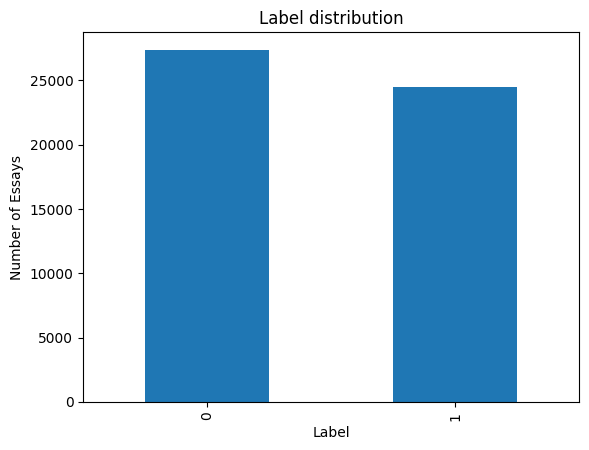

In [7]:
df["label"].value_counts().plot(kind="bar",title="Label distribution",xlabel="Label",ylabel="Number of Essays")

In [8]:
# sanity check to make sure there aren't any duplicates introduced
df["text"].unique().size

51868

<Axes: title={'center': 'Source distribution'}, xlabel='Text source', ylabel='Count'>

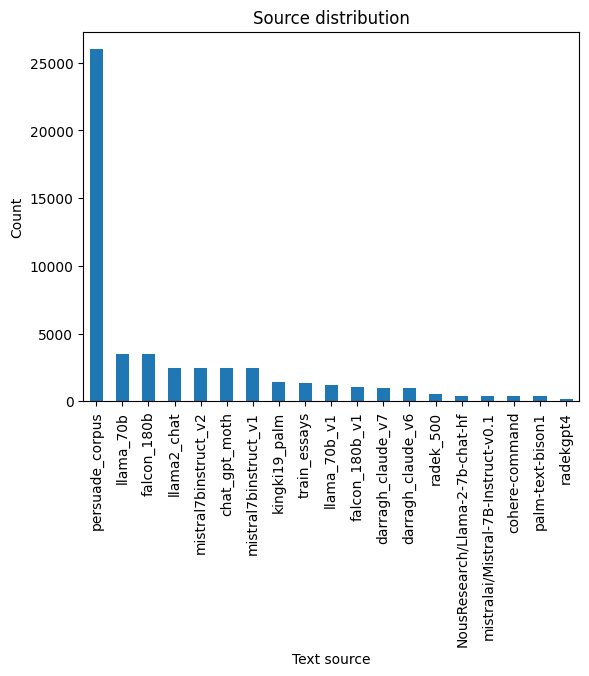

In [9]:
df["source"].value_counts().plot(kind="bar", title="Source distribution", xlabel="Text source", ylabel="Count")

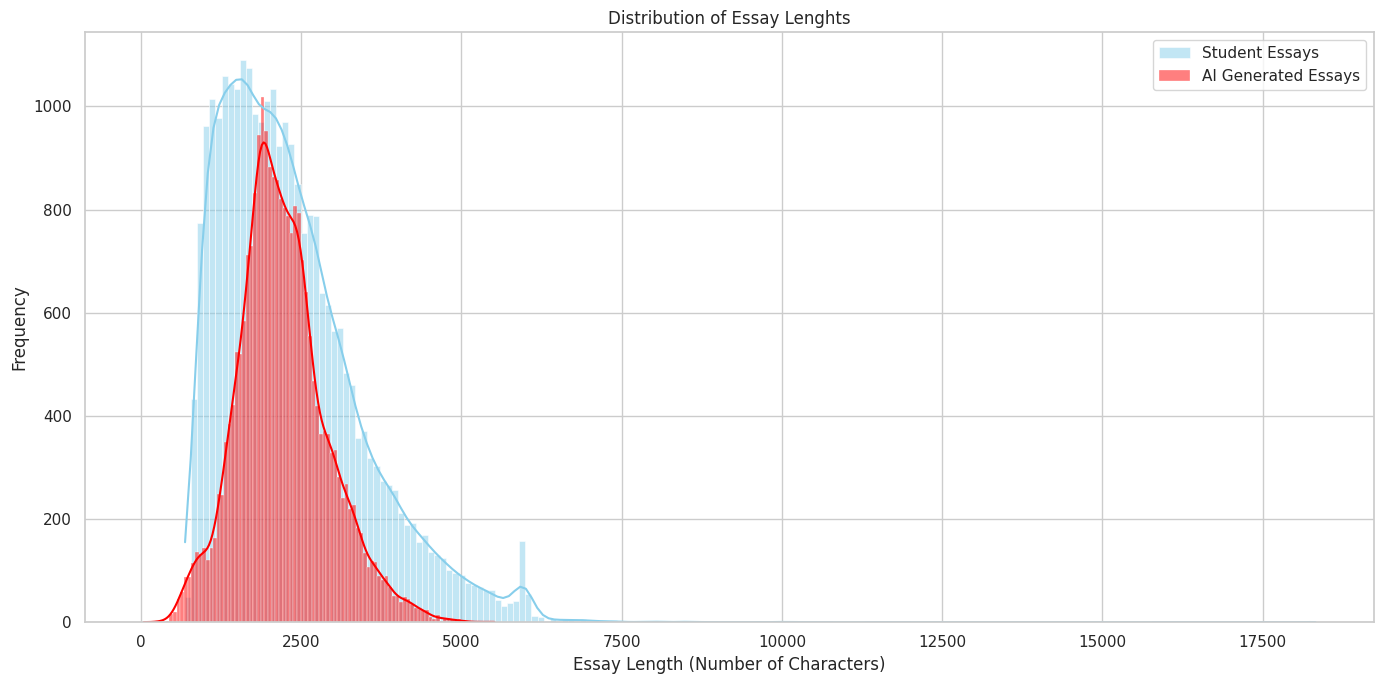

In [10]:
df['essay_length'] = df['text'].apply(len)

sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

sns.histplot(df[df['label']==0]['essay_length'], color='skyblue', label='Student Essays', kde=True)
sns.histplot(df[df['label']==1]['essay_length'], color='red',label='AI Generated Essays', kde=True)

plt.title('Distribution of Essay Lenghts')
plt.xlabel('Essay Length (Number of Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

plt.show()

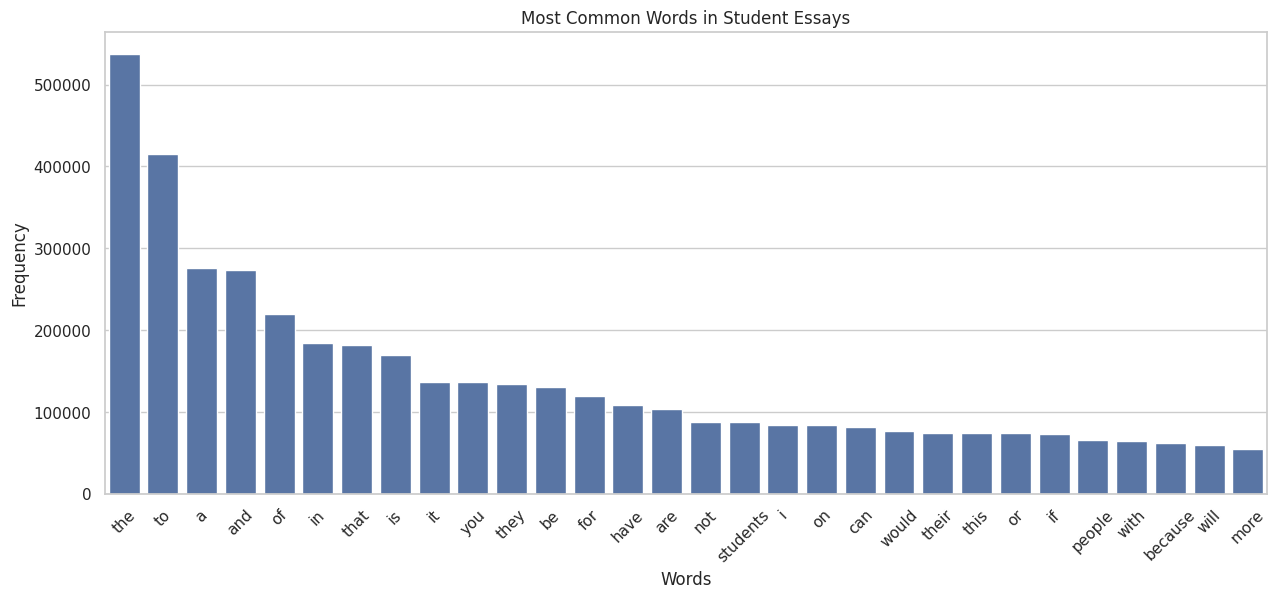

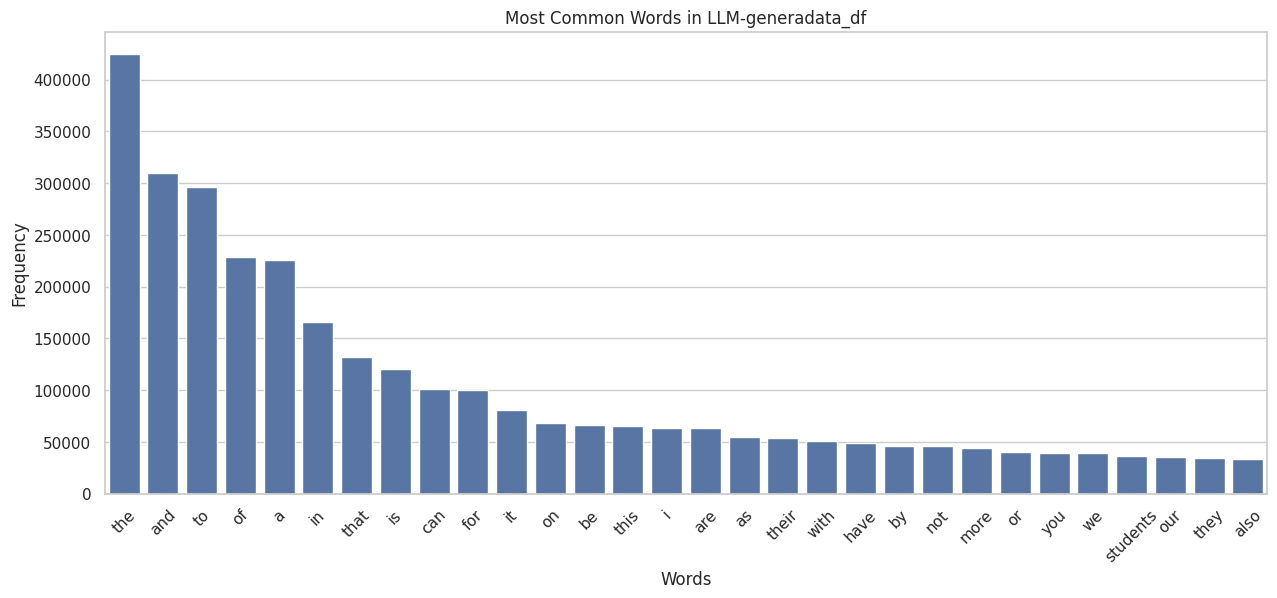

In [11]:
def plot_most_common_words(text_series, num_words=30, title="Most Common Words"):
    all_text = ' '.join(text_series).lower()
    words = all_text.split()
    word_freq = Counter(words)
    common_words = word_freq.most_common(num_words)

    plt.figure(figsize=(15, 6))
    sns.barplot(x=[word for word, freq in common_words], y=[freq for word, freq in common_words])
    plt.title(title)
    plt.xticks(rotation=45)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.show()
plot_most_common_words(df[df['label']==0]['text'], title="Most Common Words in Student Essays")
plot_most_common_words(df[df['label']==1]['text'], title="Most Common Words in LLM-generadata_df")


#### Making a validation Dataset out of the data_df using StratifiedKfold by dividing the dataset into 15 parts

In [12]:
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def preprocess(texts, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )


train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

train_encodings = preprocess(train_texts)
val_encodings = preprocess(val_texts)
test_encodings = preprocess(test_texts)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [13]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PreProcessing Data

In [14]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], torch.tensor(train_labels.tolist()))
val_dataset = TensorDataset(val_encodings['input_ids'], val_encodings['attention_mask'], torch.tensor(val_labels.tolist()))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

optimizer = AdamW(model.parameters(), lr=5e-5)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [21]:
from torch.utils.data import DataLoader
from transformers import get_scheduler
import torch
from tqdm import tqdm

num_epochs = 1
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

model.train()
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())



Epoch 1/1


Epoch 0: 100%|██████████| 2594/2594 [14:33<00:00,  2.97it/s, loss=0.00104]


In [22]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, label_batch = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits.argmax(dim=1).cpu().numpy()
            preds.extend(logits)
            labels.extend(label_batch.cpu().numpy())
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return acc, precision, recall, f1


In [23]:
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], torch.tensor(test_labels.tolist()))
test_loader = DataLoader(test_dataset, batch_size=16)
model.eval()

acc, precision, recall, f1 = evaluate(model, test_loader)
print(f"Test Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Test Accuracy: 0.9944, Precision: 0.9915, Recall: 0.9968, F1 Score: 0.9941
